# AI-ML Assignment 7

## Customer Segmentation using K-Means Clustering and Principal Component Analysis (PCA)

### Objective

The objective of this assignment is to segment mall customers into different groups using the K-Means Clustering algorithm and visualize the clusters using Principal Component Analysis (PCA).

## Libraries Used 

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Task 1: Data Understanding

In [80]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Information

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Summary Statistics

In [82]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Numerical Features

In [83]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns
print(numerical_features.tolist())

['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## Categorical Features

In [84]:
categorical_features = ["Gender"]
print(categorical_features)

['Gender']


# Task 2: Data Preprocessing

In [85]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Removing CustomerID

In [86]:
df = df.drop("CustomerID", axis=1)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Encoding Gender

In [87]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## Feature Scaling

In [88]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


# Task 3: Model Development

## Determining the Optimal Number of Clusters using the Elbow Method

In [89]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

## Elbow Curve

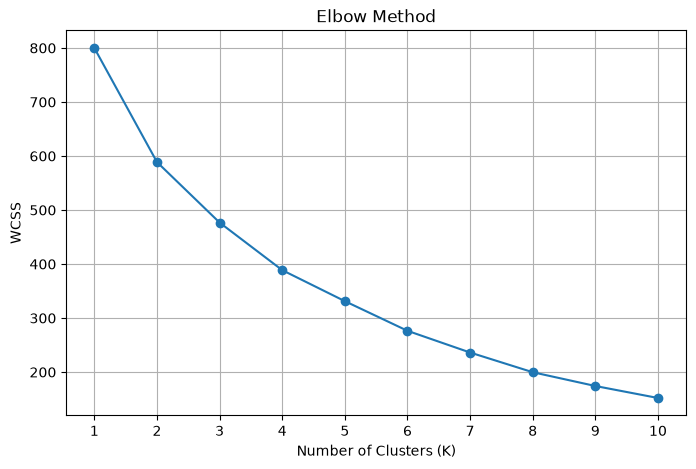

In [90]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.grid(True)
plt.savefig("images/elbow_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Training the K-Means Model

In [91]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_df)

## Assigning Cluster Labels to Customers

In [92]:
df["Cluster"] = cluster_labels
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,3
1,0,21,15,81,3
2,1,20,16,6,3
3,1,23,16,77,3
4,1,31,17,40,3


## Principal Component Analysis (PCA)

In [93]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_components,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = cluster_labels

pca_df.head()

,Principal Component 1,Principal Component 2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


# Task 4: Visualization and Evaluation

## Scatter Plot Showing Customer Clusters

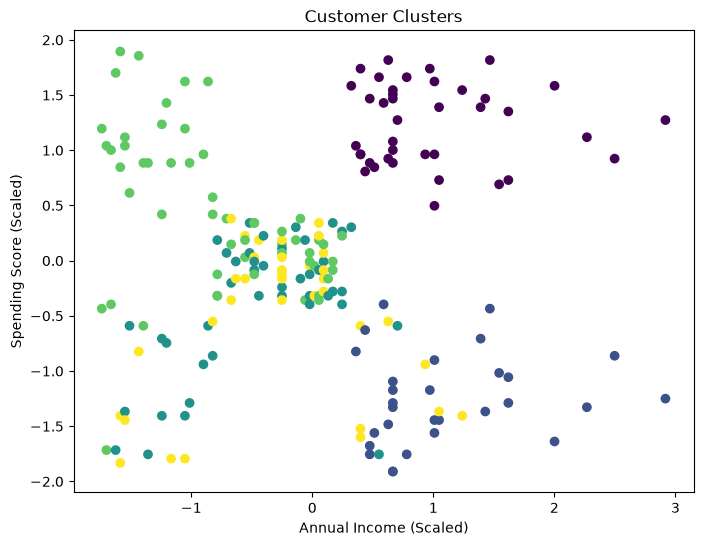

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df["Annual Income (k$)"],
    scaled_df["Spending Score (1-100)"],
    c=cluster_labels
)

plt.title("Customer Clusters")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")

plt.savefig("images/customer_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

## PCA Visualization with Cluster Labels

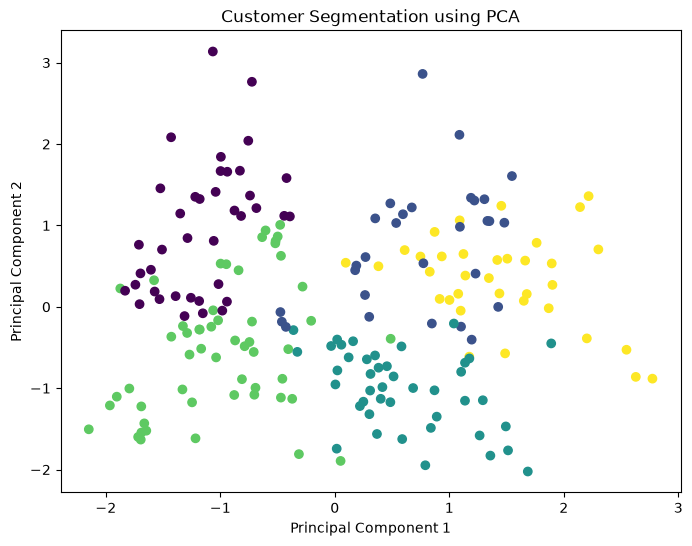

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Cluster"]
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("images/pca_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

# Observations

1. The Elbow Method indicates that **5** is the optimal number of clusters, as the WCSS decreases rapidly until K = 5 and then begins to level off.

2. PCA reduces the high-dimensional customer data into two principal components, making it easier to visualize the clusters while preserving most of the important information.

3. The scatter plots show that customers are divided into distinct groups based on similarities in annual income and spending score.

4. The identified customer groups can help businesses understand customer purchasing behaviour and create targeted marketing strategies for different segments.

# Conclusion

Customer segmentation was successfully performed using the K-Means clustering algorithm. After preprocessing the data, the Elbow Method was used to determine the optimal number of clusters, and K-Means grouped customers into meaningful segments. Principal Component Analysis (PCA) reduced the dataset to two dimensions, making it easier to visualize the clusters. These customer groups can help businesses understand customer behavior and create targeted marketing campaigns. One limitation of K-Means is that the number of clusters must be chosen in advance. An advantage of PCA is that it simplifies high-dimensional data while preserving most of the important information, making visualization and interpretation much easier.